# 🧪 Complete Jupyter Notebook — PCA (Principal Component Analysis)

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Cell 2 — Create Dataset

In [2]:
data = {
    "age": [18, 20, 22, 25, 28, 30, 32, 35, 38, 40],
    "salary": [20000, 25000, 30000, 40000, 50000,
               60000, 70000, 80000, 90000, 100000],
    "experience": [0, 1, 2, 3, 4, 5, 6, 8, 10, 12],
    "study_hours": [2, 3, 4, 5, 6, 7, 7, 8, 9, 10]
}

df = pd.DataFrame(data)

df

,age,salary,experience,study_hours
0,18,20000,0,2
1,20,25000,1,3
2,22,30000,2,4
3,25,40000,3,5
4,28,50000,4,6
5,30,60000,5,7
6,32,70000,6,7
7,35,80000,8,8
8,38,90000,10,9
9,40,100000,12,10


## Cell 3 — Separate Features

In [3]:
X = df[[
    "age",
    "salary",
    "experience",
    "study_hours"
]]

print("Original Shape:", X.shape)

Original Shape: (10, 4)


Output: `Original Shape: (10, 4)` → matlab 10 rows, 4 features.

## Cell 4 — Train-Test Split

Real ML project mein PCA se pehle split karna important hai.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (8, 4)
Testing Shape: (2, 4)


## Cell 5 — Feature Scaling

Remember:

- Training → `fit_transform()`
- Testing → `transform()`

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Cell 6 — Apply PCA

Suppose hum 4 features ko 2 components mein convert karna chahte hain:

```
4 Features → PCA → 2 Components
```

In [6]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

## Cell 7 — Check Shape

In [7]:
print("Original Features:", X_train.shape[1])
print("PCA Components:", X_train_pca.shape[1])

Original Features: 4
PCA Components: 2


## 🔥 Explained Variance

PCA ka sabse important concept: **Explained Variance Ratio**. Ye batata hai ki har principal component original data ki kitni variance/information capture kar raha hai.

Example (sirf samajhne ke liye): PC1 → 0.65 (65%), PC2 → 0.25 (25%), total approximately 90%.

⚠️ Asli numbers dataset par depend karte hain. Is dataset mein features aapas mein bahut correlated hain (age, salary, experience, study_hours sab saath badhte hain), isliye PC1 akela hi bahut zyada variance capture karega.

In [8]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.98904769 0.00759768]


In [9]:
print(
    "Total Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

Total Explained Variance: 0.9966453734319985


## 🔹 Cumulative Explained Variance

Agar hum decide karna chahte hain ki kitne components rakhne chahiye:

In [10]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_train_scaled)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

print(cumulative_variance)

[0.98904769 0.99664537 0.99979682 1.        ]


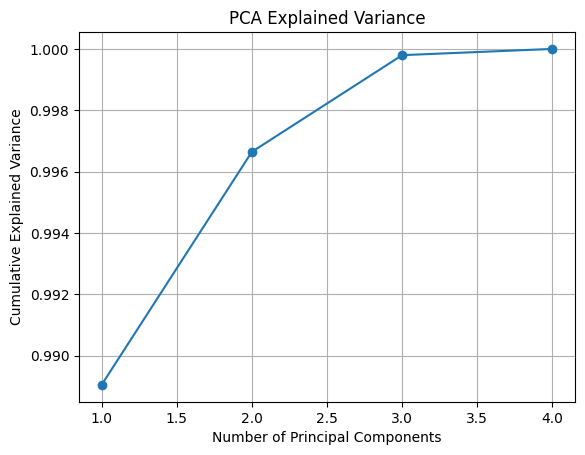

In [11]:
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

Graph dekh kar information requirement ke according components choose karo. Example: agar 2 components → 90%, 3 → 96%, 4 → 100% ho, to 2 ya 3 components choose kar sakte ho.

## 🔥 PCA Visualization

2 components hain, to 2D plot bana sakte hain:

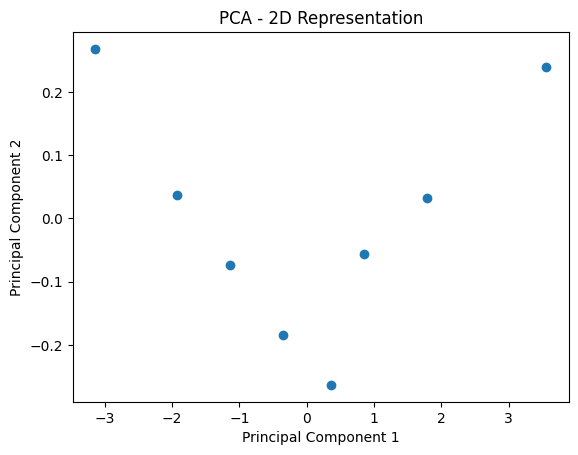

In [12]:
plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Representation")
plt.show()

- `X_train_pca[:, 0]` → All rows ka PC1
- `X_train_pca[:, 1]` → All rows ka PC2

## 🔹 PCA Components ko DataFrame mein Convert

In [13]:
pca_df = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,0.358154,-0.263131
1,-3.139645,0.268072
2,1.779555,0.031823
3,-1.921339,0.037535
4,3.558733,0.239098


Notice: Original `age, salary, experience, study_hours` ab `PC1, PC2` ban gaye.

## ➕ Bonus — Kaunsa Feature kis Component mein kitna hai? (Loadings)

`pca.components_` batata hai ki har principal component mein original features ka kitna contribution hai.

In [14]:
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["PC1", "PC2"]
)

loadings

,age,salary,experience,study_hours
PC1,0.502031,0.501018,0.498209,0.498733
PC2,-0.212557,0.181591,0.694856,-0.662585
